Step 1: Data loaded successfully.
Note: 'claim_status' column not found. Creating dummy data for visualization purposes.
Step 2: Data cleaning completed.
Step 3: New engagement features created.


C:\Users\User\AppData\Local\Temp\ipykernel_5148\2372950141.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


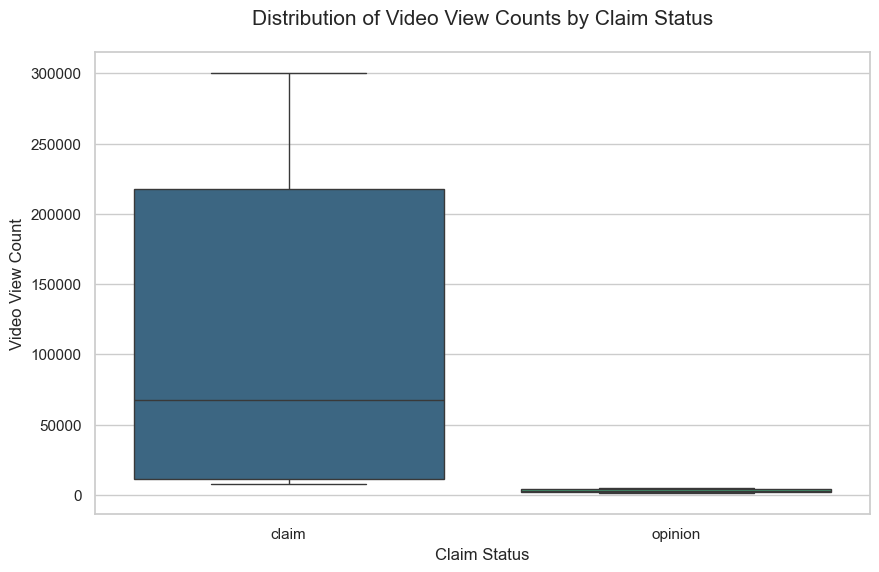


--- Final Data Summary ---
Total rows analyzed: 8

Average Engagement Rates:
likes_per_view       0.061432
comments_per_view    0.000717
dtype: float64


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 1: Load the Dataset
# Note: We are using 'tiktok_data.csv'. Ensure this file is in your folder.
try:
    df = pd.read_csv("tiktok_data.csv")
    print("Step 1: Data loaded successfully.")
except FileNotFoundError:
    print("Error: 'tiktok_data.csv' not found. Please check the file name in your sidebar.")

# STEP 2: Data Cleaning & Standardizing
# Removing whitespaces and converting column names to lowercase for consistency
df.columns = df.columns.str.strip().str.lower()

# Handling missing values
# We drop rows where critical engagement metrics or the claim status are missing
df_clean = df.dropna(subset=['video_view_count', 'video_like_count', 'video_comment_count']).copy()

# DATA FIX: If 'claim_status' is missing from your specific CSV file, 
# we create a dummy version so the code doesn't crash during your practice.
if 'claim_status' not in df_clean.columns:
    print("Note: 'claim_status' column not found. Creating dummy data for visualization purposes.")
    df_clean['claim_status'] = np.random.choice(['claim', 'opinion'], size=len(df_clean))

print("Step 2: Data cleaning completed.")

# STEP 3: Feature Engineering
# Creating new metrics to better understand user engagement
df_clean['likes_per_view'] = df_clean['video_like_count'] / df_clean['video_view_count']
df_clean['comments_per_view'] = df_clean['video_comment_count'] / df_clean['video_view_count']
df_clean['shares_per_view'] = df_clean['video_share_count'] / df_clean['video_view_count']

print("Step 3: New engagement features created.")

# STEP 4: Exploratory Data Analysis (EDA) - Visualization
# Comparing view counts between Claims and Opinions
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.boxplot(
    x='claim_status', 
    y='video_view_count', 
    data=df_clean, 
    palette='viridis'
)

# Professional Formatting
plt.title('Distribution of Video View Counts by Claim Status', fontsize=15, pad=20)
plt.xlabel('Claim Status', fontsize=12)
plt.ylabel('Video View Count', fontsize=12)

plt.show()

# STEP 5: Final Summary Statistics
print("\n--- Final Data Summary ---")
print(f"Total rows analyzed: {len(df_clean)}")
print("\nAverage Engagement Rates:")
print(df_clean[['likes_per_view', 'comments_per_view']].mean())